In [15]:

import numpy as np
import pandas as pd


# Python的内置类型，表示没有返回  或者没有初始化的情况   NoneType
type(None)

# # 表述的是数值的特殊值   不是一个数   float
type(np.nan)

# # 表述的数据的可用以及不可用性   pandas._libs.missing.NAType
type(pd.NA)

s = pd.Series([np.nan, None, pd.NA])
s.isnull()
s.isna()

s.notnull()
s.notna()


0    False
1    False
2    False
dtype: bool

In [27]:
# 加载带缺失值的文件
df = pd.read_csv("../data/weather_withna.csv")
# df.head(100)
# 如果导入的数据有空数据  默认用缺失值进行填充
df.tail()

# # 如果不想用缺失值进行填充  就保留空值   通过keep_default_na参数设置是否将空白值设置为缺失值
df = pd.read_csv("../data/weather_withna.csv",keep_default_na=False)
df.tail()

# # 可通过na_values参数将指定值设置为缺失值。
df = pd.read_csv("../data/weather_withna.csv",na_values="2015-12-31")
df.tail()

# # 查看缺失值的数量      df.isna()=>返回一个df，里面的数据都是布尔类型，  True=1  False=0   ，所以可以通过sum()计算缺失值
df.isna().sum()




date               1
precipitation    303
temp_max         303
temp_min         303
wind             303
weather          303
dtype: int64

<Axes: >

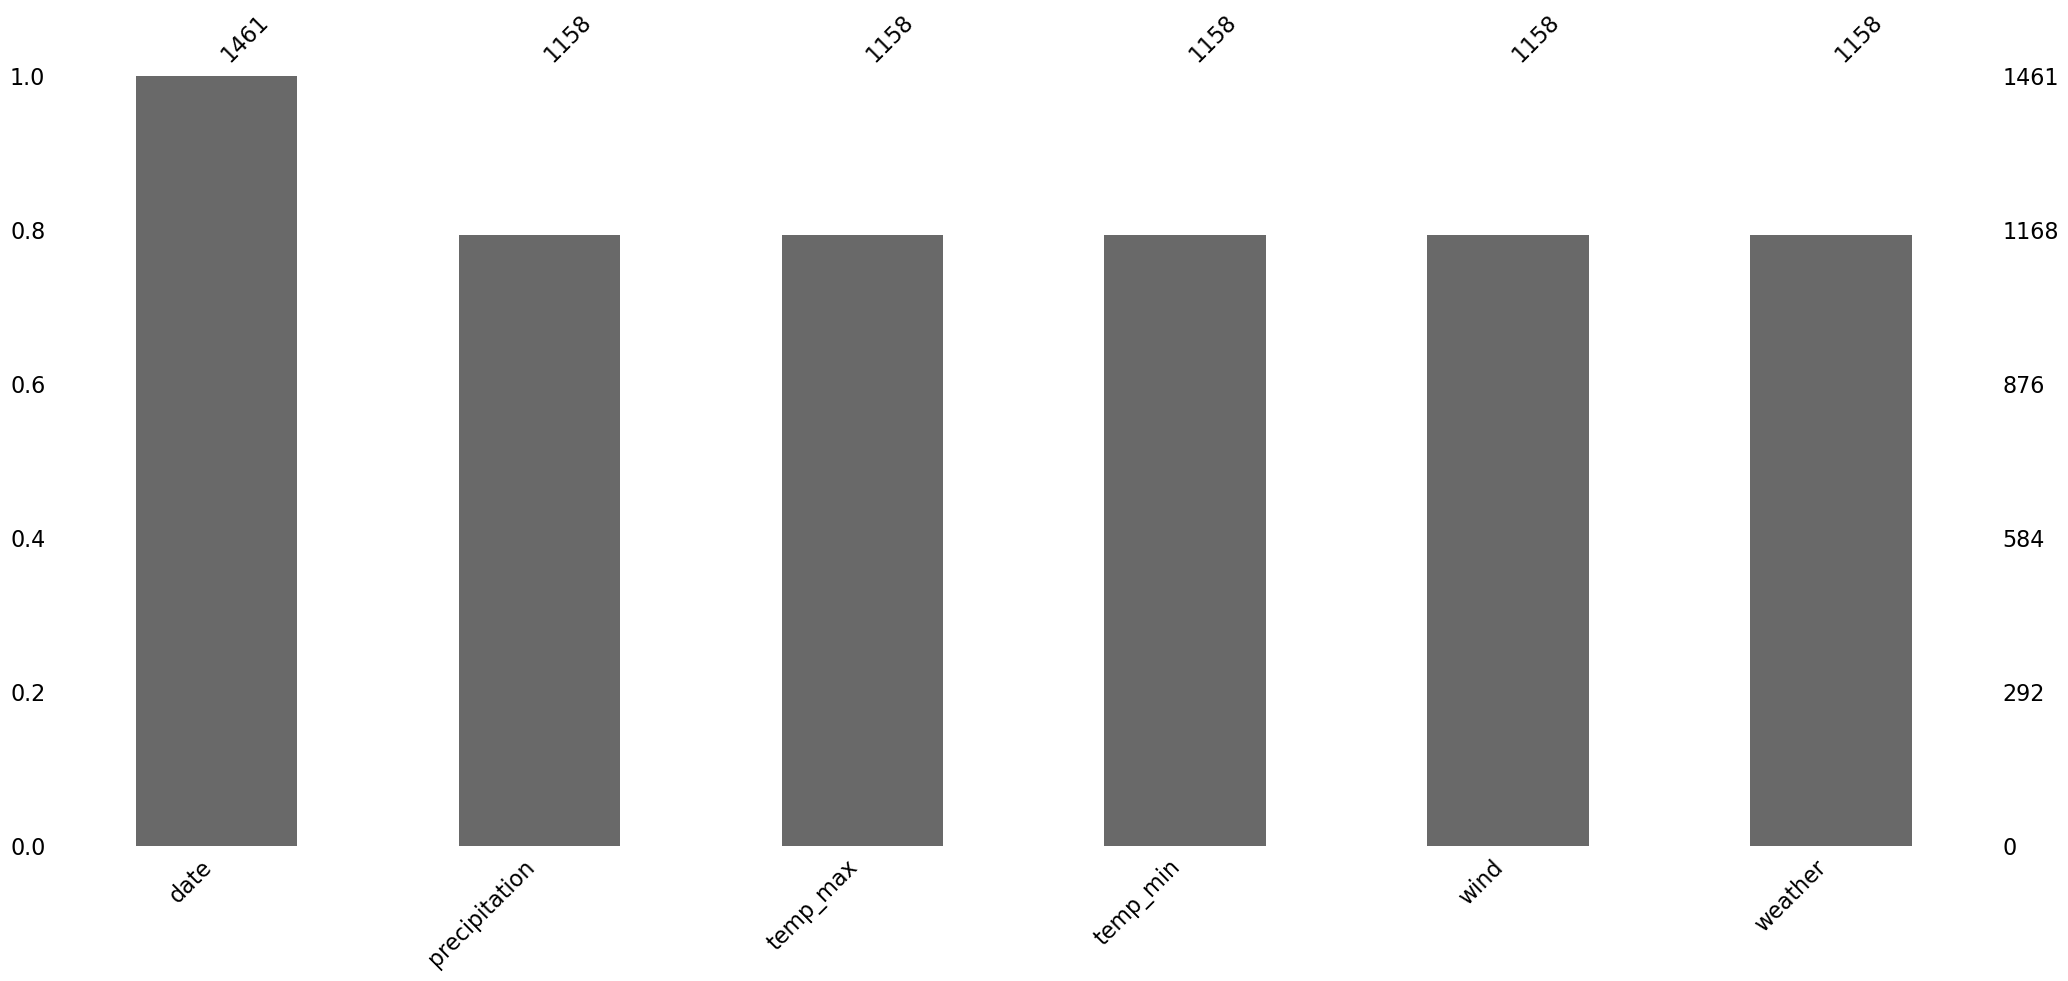

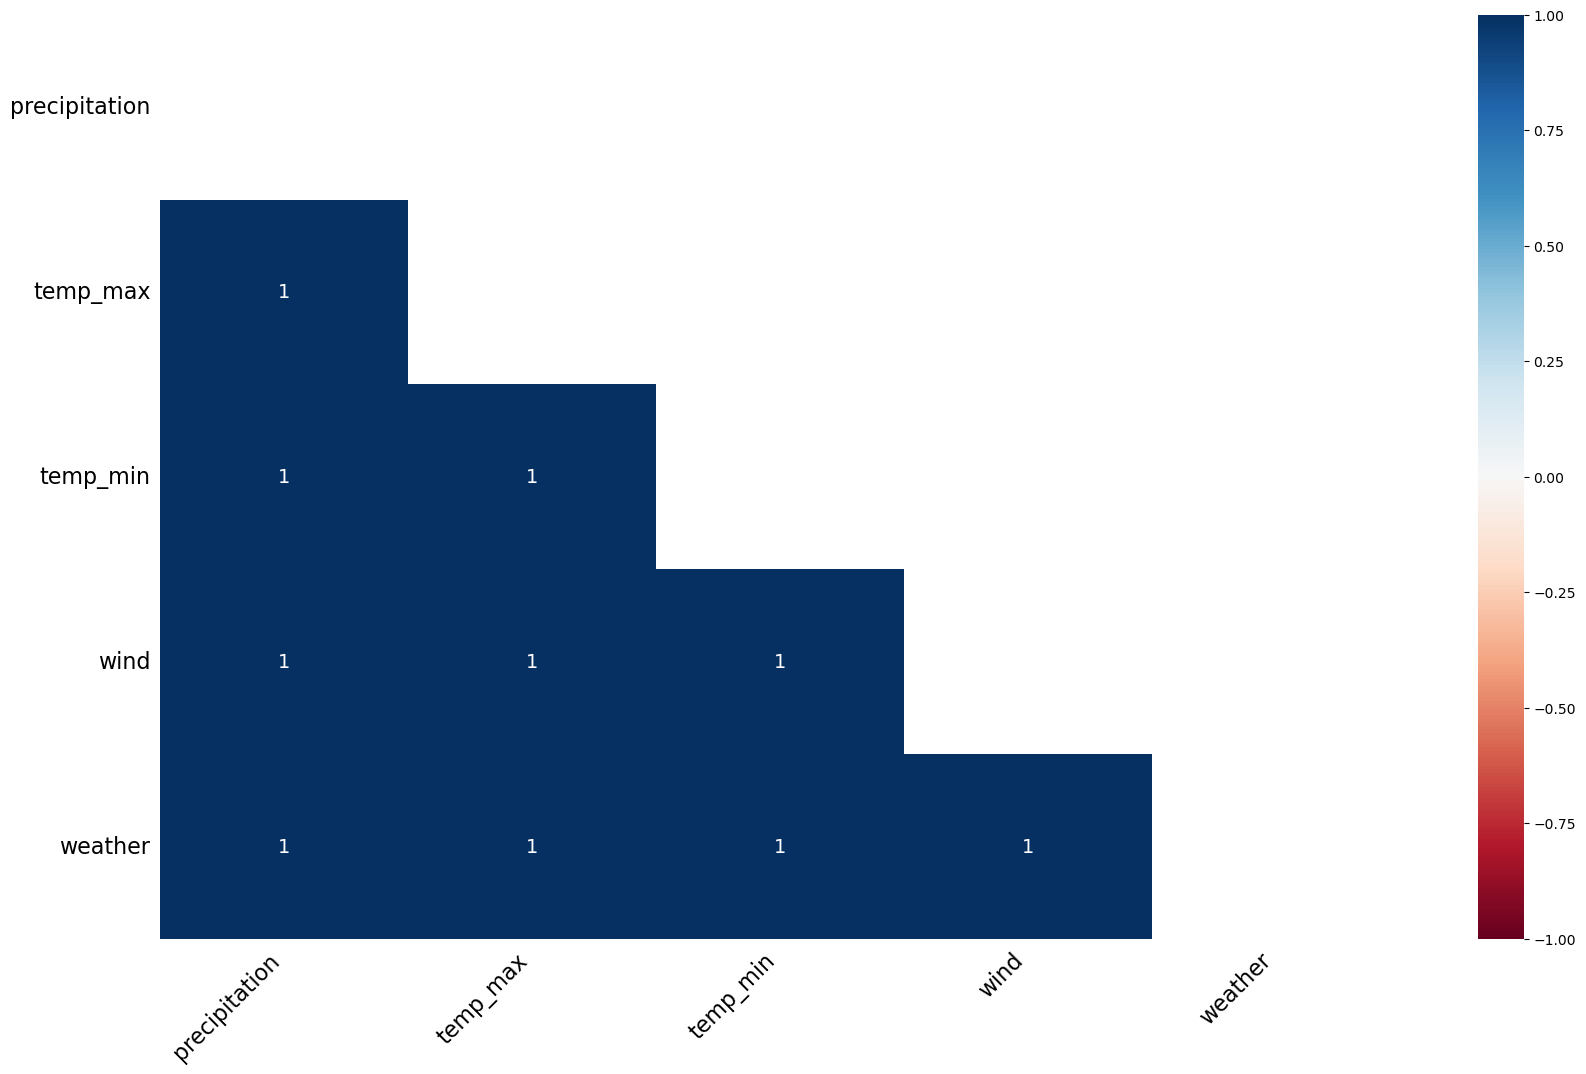

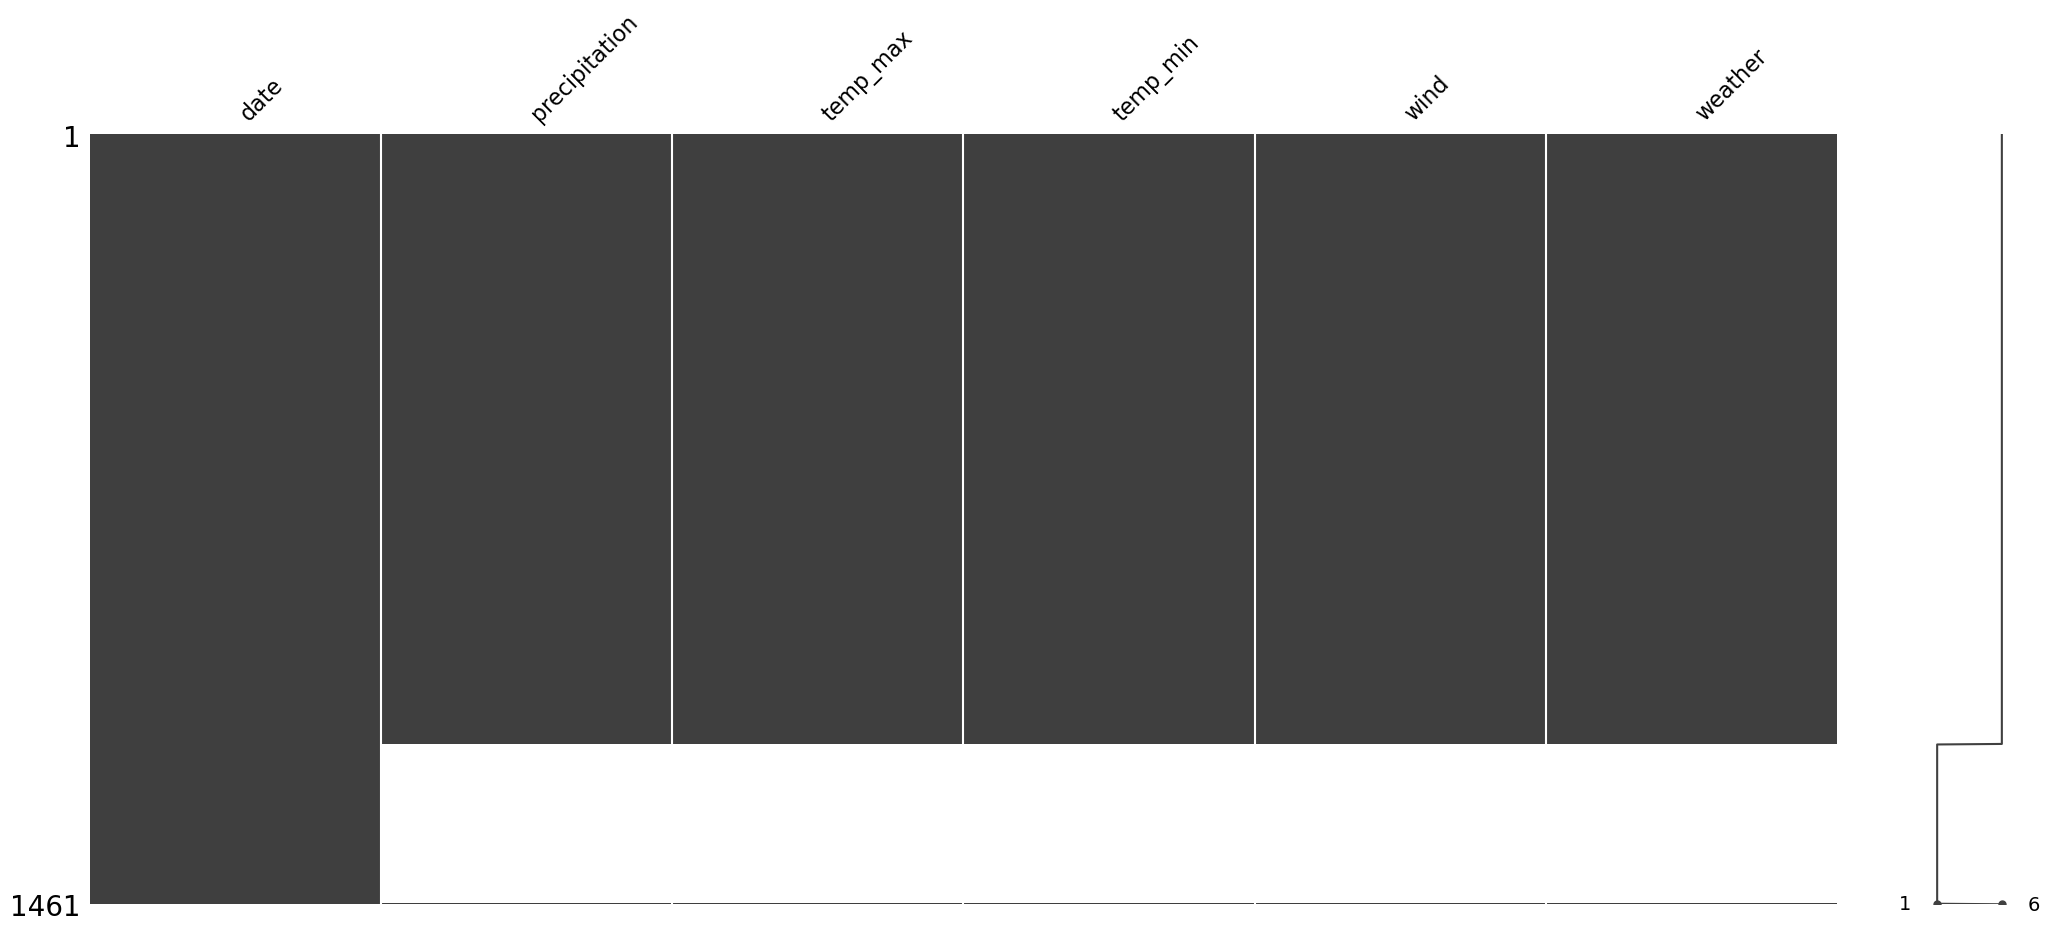

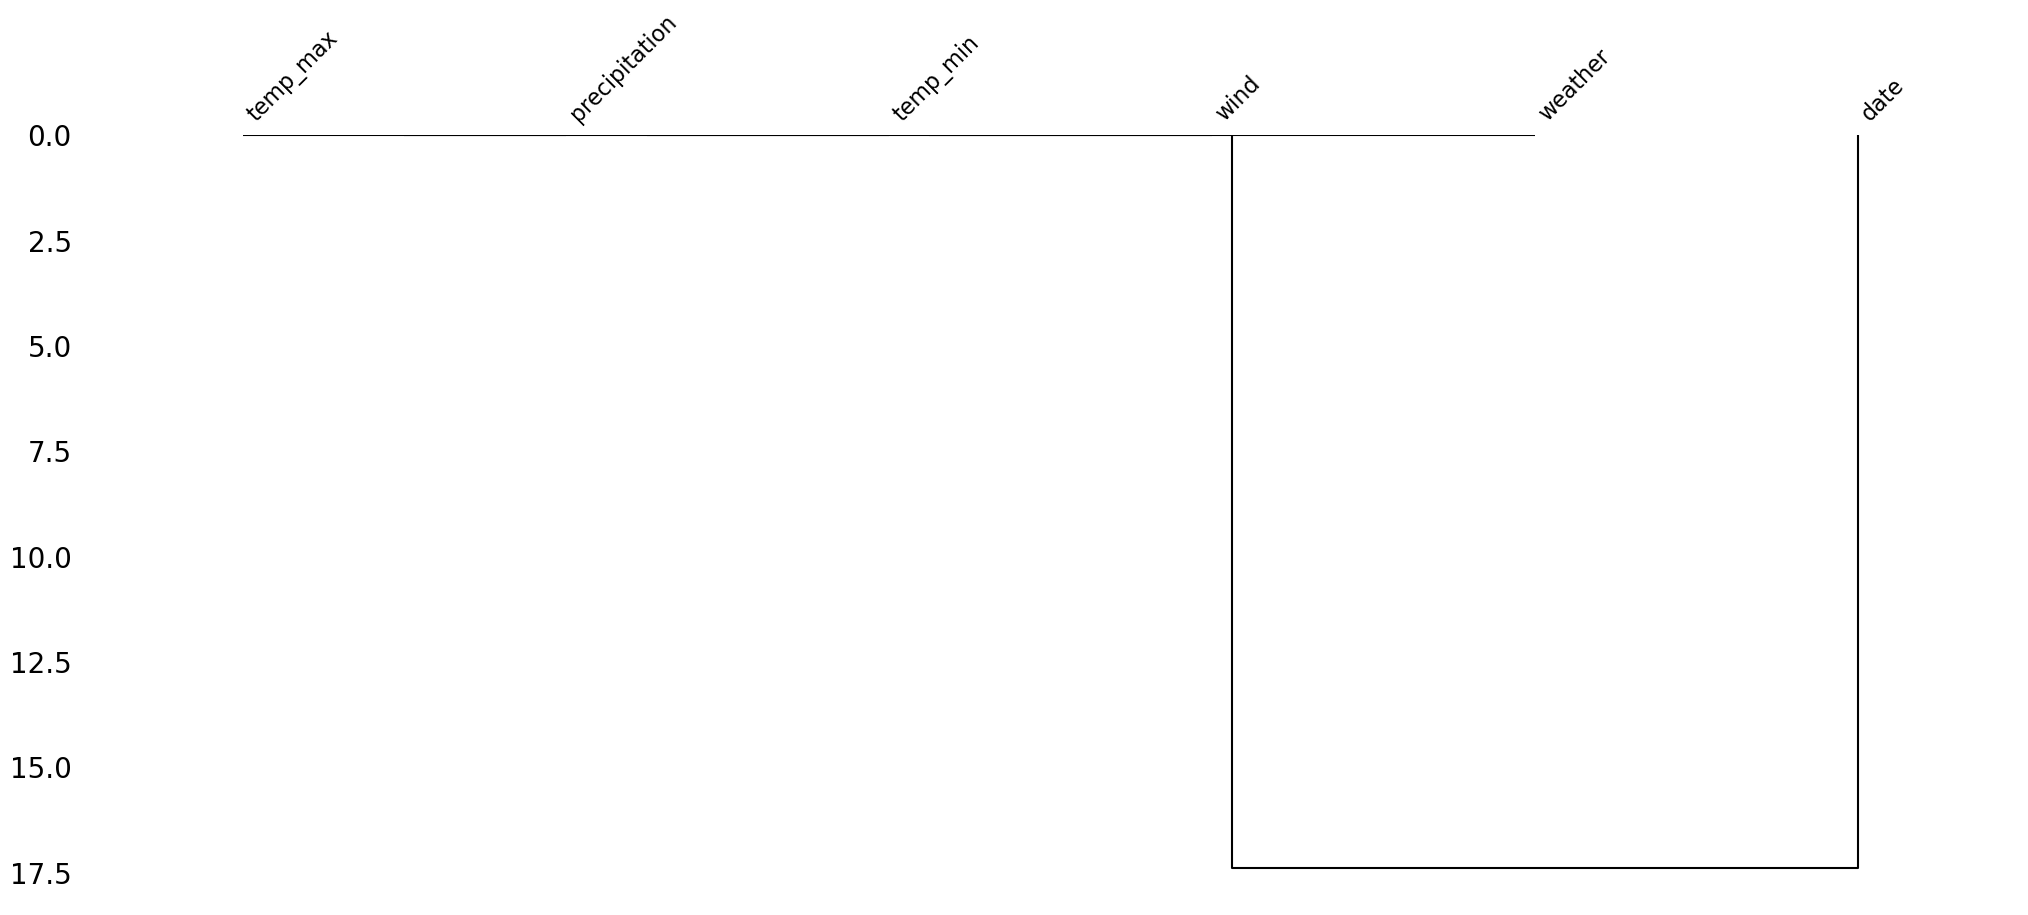

In [18]:
# ============================================================
# missingno：专门用来「可视化缺失值」的库
# 前面 df.isna().sum() 是把缺失值【数】出来；missingno 是把它【画】出来，更直观
# 安装（在 notebook 单元格里跑，会装到当前内核环境）：
#     %conda install -c conda-forge missingno -y
# 依赖 matplotlib / seaborn，做数据分析一般已装好
# ============================================================
import missingno as msno

df = pd.read_csv("../data/weather_withna.csv")

# 【条形图】每列「非缺失值」的数量
#   - 横轴=各列，柱子越高 → 该列非空数据越多；柱子矮的列就是缺得多的列
#   - 本数据：date 几乎是满的，其余 5 列各缺 303 个 → 柱子会明显矮一截
#   - 一句话：快速扫一眼哪几列缺失最严重
msno.bar(df)

# 【热力图】列与列之间「缺失的相关性」（nullity correlation，范围 -1 ~ 1）
#   注意：画的不是【数值】的相关性，而是「缺不缺」这件事的相关性
#   - 接近 +1：两列经常【一起缺失】（A 缺时 B 往往也缺）
#   - 接近 -1：两列【此消彼长】（A 缺时 B 往往有值）
#   - 接近  0：两列缺不缺互不相关
#   用处：判断缺失是不是【成片】出现 → 决定该「整行删」还是「按列单独填」
#
#   ★本数据实测结果：5 个值列两两相关性【全是 +1】（整张图深蓝、数字全为 1）
#     → 说明这 5 列【总是一起缺失】：就是同样的那 303 行，5 列同时为空
#       （相当于"整行都空，只剩 date 有值"）
#     → 缺失是【成片整行】出现的，不是零散随机
#     → 处理策略：直接 dropna() 删整行最合理（单独填某一列意义不大，这些本就是空行）
#   注1：date 没出现在图里——它没有缺失值，"缺失"无变化算不出相关性，missingno 自动剔除
#   注2：图只画【左下三角】——相关性矩阵对称(A对B=B对A)、对角线恒为1，省掉重复部分
#        （这也是最上面 precipitation 行、最右边 weather 列空着的原因）
msno.heatmap(df)

# 【补充】另外两个常用图（按需放开运行）：
msno.matrix(df)      # 每行画一条，缺失处留白 → 看缺失是随机分布还是集中在某段（按 date 排的天气数据很适用）
msno.dendrogram(df)  # 树状图，把「缺失模式相似」的列聚到一起


In [20]:
# 1）Series剔除缺失值
s = pd.Series([1, pd.NA, None])
s.dropna()

0    1
dtype: object

In [ ]:
# 2）DataFrame剔除缺失值
# 无法从DataFrame中单独剔除一个值，只能剔除缺失值所在的整行或整列。
df = pd.DataFrame([[1, pd.NA, 2], [2, 3, 5], [pd.NA, 4, 6]])
df
# 默认情况下，dropna()会剔除任何包含缺失值的整行数据。
df.dropna()  # 默认 axis=0，剔除行
# axis=1 会剔除任何包含缺失值的整列数据。
df.dropna(axis=1,how='all')  # 只有当整列都是缺失值时才剔除



,0,1,2
0,1,<NA>,2
1,2,3,5
2,<NA>,4,6


In [30]:
df = pd.DataFrame([[1, pd.NA, 2], [pd.NA, pd.NA, 5], [pd.NA, pd.NA, pd.NA]])
# df.dropna(how='all',axis=1)

# thresh=n   至少有n个值不是缺失值 当前行|列数据才会保留
df.dropna(thresh=2)


,0,1,2
0,1,<NA>,2


In [33]:
# 可以通过设置subset参数来设置某一列有缺失值则进行剔除。
df = pd.DataFrame([[1, pd.NA, 2], [pd.NA, pd.NA, 5], [pd.NA, pd.NA, pd.NA]])
df
df.dropna(subset=[1])

,0,1,2


In [56]:
# 填充缺失值
# 1）使用固定值填充
# 通过fillna()方法，传入值或字典进行填充。
df = pd.read_csv("../data/weather_withna.csv")
df.fillna(0, inplace=True)
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,0.0,0.0,0.0,0.0,0
1457,2015-12-28,0.0,0.0,0.0,0.0,0
1458,2015-12-29,0.0,0.0,0.0,0.0,0
1459,2015-12-30,0.0,0.0,0.0,0.0,0
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [59]:
# 使用字典来填充
df = pd.read_csv("../data/weather_withna.csv")
df.fillna({"temp_max":60,"temp_min":-60}, inplace=True)
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,NaN,60.0,-60.0,NaN,NaN
1457,2015-12-28,NaN,60.0,-60.0,NaN,NaN
1458,2015-12-29,NaN,60.0,-60.0,NaN,NaN
1459,2015-12-30,NaN,60.0,-60.0,NaN,NaN
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [72]:
# 通过fillna()方法，传入统计后的值进行填充。
df = pd.read_csv("../data/weather_withna.csv")
df.fillna(df[["precipitation","temp_max","temp_min","wind"]].mean(), inplace=True)
df.tail()


,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,3.052332,15.851468,7.877202,3.242055,NaN
1457,2015-12-28,3.052332,15.851468,7.877202,3.242055,NaN
1458,2015-12-29,3.052332,15.851468,7.877202,3.242055,NaN
1459,2015-12-30,3.052332,15.851468,7.877202,3.242055,NaN
1460,2015-12-31,20.600000,12.200000,5.000000,3.800000,rain


In [76]:
# 通过ffill()或bfill()方法使用前面或后面的有效值填充。
df = pd.read_csv("../data/weather_withna.csv")
# df.ffill(inplace=True)
df.bfill(inplace=True)
df.tail()

,date,precipitation,temp_max,temp_min,wind,weather
1456,2015-12-27,20.6,12.2,5.0,3.8,rain
1457,2015-12-28,20.6,12.2,5.0,3.8,rain
1458,2015-12-29,20.6,12.2,5.0,3.8,rain
1459,2015-12-30,20.6,12.2,5.0,3.8,rain
1460,2015-12-31,20.6,12.2,5.0,3.8,rain


In [49]:
s = pd.Series([1, np.nan, 3, 4, np.nan, 6])
s.interpolate(inplace=True)  # 默认 method='linear'，线性插值
s

0    1.0
1    2.0
2    3.0
3    4.0
4    5.0
5    6.0
dtype: float64